# SeaBASS data to CMAP

#### Krista Longnecker
20 June 2026\
23 September 2026\
28 September 2026

BIOS-SCOPE has some data at SeaBASS that can be prepared for CMAP. SeaBASS data download is an offline process, so use data requested for download and stored locally (e.g., not synced to GitHub).\
This file will focus on the Flowcam data as they are ready and I have all the values I need for calculations. The net samples are not ready yet.

In [322]:
%reset -f

In [323]:
import os
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
import math

#used this to step into the function and debug it, also need line with set_trace()
from IPython.core.debugger import set_trace
import warnings

#SB_support from NASA's website: https://seabass.gsfc.nasa.gov/wiki/readsb_python
from SB_support import readSB

In [324]:
# Suppress a specific future warning by its exact text or a Regex pattern
warnings.filterwarnings(
    "ignore", 
    message="The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes", 
    category=FutureWarning
)

In [325]:
#Check that an Excel file exists for the variable metadata:
if os.path.exists('CMAP_variableMetadata_additions.xlsx'):
    print('Found Excel file with metadata')
else:
    #You cannot proceed without the file, so stop the script if it's not found
    print(f"No Excel file with metadata found")
    sys.exit(1)
    
#will add a new worksheet with the variables from Amy's data

Found Excel file with metadata


In [326]:
#need to know what type of data each file contains, use a function to match filenames
def findSampleType(oneName):
    '''Need to filter the type of sample based on the filename. We have four choices:
    # CTDauto (name will contain FlowcamBottleAuto)
    # CTDtrigger (name will contain FlowcamBottleTrigger)
    # netZooscan (name will contain ZooScanNet)
    # netFlowcam (name will contain FlowcamNet)
    
    Easiest to parse out cruise name at the same time
    '''
    
    #Three types of files possible, need to the prefix to find the placement of the cruise information
    prefix = "\\archive\\PVST_BATS_PLANKTON_"
    prefixHPLC = "_HPLC_"
    prefixReport = "\\archive\Maas_15-18_"
    
    if [item for item in [oneName] if 'FlowcamBottleAuto' in item]:
        sType = 'FlowcamBottleAuto'
        #messy...AI suggestion but seems like there should be a better way
        cruise = oneName[oneName.find(prefix) + len(prefix) : oneName.find(prefix) + len(prefix) + 6]
        
    elif [item for item in [oneName] if 'FlowcamBottleTrigger' in item]:
        sType = 'FlowcamBottleTrigger'
        cruise = oneName[oneName.find(prefix) + len(prefix) : oneName.find(prefix) + len(prefix) + 6]
        
    elif [item for item in [oneName] if 'ZooScanNet' in item]:
        sType = 'ZooScanNet'
        cruise = oneName[oneName.find(prefix) + len(prefix) : oneName.find(prefix) + len(prefix) + 6]
        
    elif [item for item in [oneName] if 'FlowcamNet' in item]:
        sType = 'FlowcamNet'
        cruise = oneName[oneName.find(prefix) + len(prefix) : oneName.find(prefix) + len(prefix) + 6]
              
    elif [item for item in [oneName] if '_HPLC_' in item]:
        sType = 'HPLC'
        #cruise = oneName[oneName.find(prefixHPLC) + len(prefixHPLC) : oneName.find(prefixHPLC) + len(prefixHPLC) + 6]    
        #need to change this...cruise will always be before 'HPLC'...otherwise multiple prefixes
        cruise = oneName[oneName.find(prefixHPLC) - len(prefixHPLC) : oneName.find(prefixHPLC)]  
        
    elif [item for item in [oneName] if 'report' in item]:
        sType = 'report'
        cruise = oneName[oneName.find(prefixReport) + len(prefixReport):oneName.find(prefixReport) + len(prefixReport) + 6]
        
    else: 
        print('Something is wrong')
        
    return sType, cruise

In [327]:
#The math for the calculation is in the header of each file. From Amy I have 
# CTD- auto: !to calculate abundance of a particle for FlowCam Niskin Bottle Sample (Auto mode) (each row is a particle): abundance (#/L) = ((particle (unitless) / volume_imaged_mL (mL))
# CTD- trigger: !to calculate abundance of a particle for FlowCam Niskin Bottle Sample (Trigger mode) (each row is a particle): abundance (#/L) = ((particle (unitless) / volume_imaged_mL (mL))
# net - zooscan: !to calculate abundance of a particle (each row is a particle): abundance (#/L) = particle (unitless) * splitfraction (unitless) / volnet (L)
# net - flowcam: !to calculate abundance of a particle for Auto (each row is a particle): abundance (#/L) = (((particle (unitless) / volume_imaged_mL (mL)) * particle_dilution_factor (mL)) * splitfraction (unitless)) / volnet (L))
def doTheMath(df,sampleType,volName):
        if sampleType == 'FlowcamBottleAuto':
            df['sampleType'] = sampleType
            #from header:
            #!volume = acq_vol_img divided by 1000. This is the total volume imaged by FlowCam. 
            #!Use this volume in particle concentration calculations in AutoImage mode.
            #from Amy
            ## abundance (#/L) = ((particle (unitless) / volume_imaged_mL (mL))
            # update 9/23/2026 - have two versions of column headers, varies by cruise use 'volName' to sort out options
            # careful: volume has units of L, while volume_imaged is mL
            
            #turns out that only some of the cruises have biovolume calculated, put that calculation here as well.
            #note the two ** means this is an exponential operator
            df['biovolume_calculated'] = (math.pi * (df['equivalent_spherical_diameter']**3)) / 6

            # for the abundance per L this is 1/volume because each ROW is a particle           
            if volName == 'volume_imaged_ml':
                df['abundance_perL'] = (1 / df['volume_imaged_ml'])*1000
                #also do biovolume as a volumetric measure
                df['biovolume_perL'] = (df['biovolume_calculated'] / df['volume_imaged_ml'])*1000          
            else:
                df['abundance_perL'] = (1 / df['volume'])
                df['biovolume_perL'] = df['biovolume_calculated'] / df['volume'] 
                
        elif sampleType == 'FlowcamBottleTrigger':
            df['sampleType'] = sampleType
            #from header:
            #!volfilt = acq_vol_proc divided by 1000. This is the total volume pulled through FlowCam. 
            #Use this volume in particle concentration calculations in Trigger mode.
            #from Amy
            ## abundance (#/L) = ((particle (unitless) / volume_imaged_mL (mL))           
            # update 9/23/2026 - have two versions of column headers, varies by cruise use 'volName' to sort out options
            # careful: volume has units of L, while volume_imaged is mL
            
            df['biovolume_calculated'] = (math.pi * (df['equivalent_spherical_diameter']**3)) / 6
                
            if volName == 'volume_imaged_ml':
                df['abundance_perL'] = (1 / df['volume_imaged_ml'])*1000
                df['biovolume_perL'] = (df['biovolume_calculated'] / df['volume_imaged_ml'])*1000   
            else:
                df['abundance_perL'] = (1 / df['volfilt'])
                df['biovolume_perL'] = df['biovolume_calculated'] / df['volume']                     
                                
        elif sampleType == 'ZooScanNet':
            df['sampleType'] = sampleType
            #from header:
            #!volnet = volume calculated from net flowmeter in L
            #!splitfraction = the fraction of the sample that was diluted (for example if you split the sample 4 times that is 1/16th of the total sample so 16 is the value used)
            #from Amy
            ## abundance (#/L) = particle (unitless) * splitfraction (unitless) / volnet (L) #from Amy
            if 'splitfraction' in df.columns:
                df['abundance_perL'] = (1 * df['splitfraction'] / df['volnet'])
            else:
                #seem to have two formats for these data
                df['abundance_perL'] = -999
                                    
        elif sampleType == 'FlowcamNet':
            df['sampleType'] = sampleType
            #from header
            #!volume_sampled_mL= FlowCam's Sample_Volume_Aspirated - total volume of sample pulled into the Flowcam system by the pump or syringe
            #!volume_imaged_mL = FlowCam's Fluid_Volume_Imaged - the exact volume of fluid within the camera's field of view and captured as images used for Auto mode
            #!volnet = volume calculated from net flowmeter in L
            #!splitfraction = the fraction of the sample that was diluted (for example if you split the sample 4 times that is 1/16th of the total sample so 16 is the value used)
            #!particle_dilution_factor (mL) = Term to encompass the conversion from particles to particles/mL - in this case the volume the net sample is diluted into before passing it through the FlowCam

            if 'volume_imaged_ml' in df.columns:
                ## abundance (#/L) = (((particle (unitless) / volume_imaged_mL (mL)) * particle_dilution_factor (mL)) * splitfraction (unitless)) / volnet (L))
                #as received is missing one "(" at the beginning
                df['abundance_perL'] = ((((1 / df['volume_imaged_ml']) * df['particle_dilution_factor']) * df['splitfraction']) / df['volnet'])
            else:
                #seem to have two formats for these data
                df['abundance_perL'] = -999
                #set_trace()
            
        elif sampleType == 'HPLC':
            df['sampleType'] = sampleType
            #no added math needed (pigment data are : mg/m^3)
            df['abundance_perL'] = pd.NA
                                    
        elif sampleType == 'report':
            df['sampleType'] = sampleType
            #do nothing
            df['abundance_perL'] = pd.NA
                                    
            
        return df

In [328]:
#get the list of unique cruises from the folder structure (need this for the CMAP submission)
# Target directory path
folder_path = 'data/SeaBASS/Maas/PVST_BATS_PLANKTON'

# Filter for folders only (requires joining path to verify accurately)
unCruises = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]


#go find the data in the data folder (it is in .gitignore, so it will not end up at GitHub). Makes a list.
# I know the folder is there, so no need to make the folder
# folder = "data"
SBstring = ".sb"
matching_files = []

os.chdir(".")

for root, dirs, files in os.walk(folder_path):
    for file in files:
        full_path = os.path.join(root, file)
        # Change 'file' to 'full_path' if you want to search the entire folder path
        if SBstring in file:  
            matching_files.append(full_path)

In [329]:
unCruises

['AE2503',
 'AE2506',
 'AE2510',
 'AE2512',
 'AE2513',
 'AE2515',
 'AE2517',
 'AE2522',
 'AE2523',
 'AE2524',
 'AE2528',
 'AE2529',
 'AE2531',
 'AE2602',
 'AE2603',
 'AE2605',
 'AE2606',
 'AE2608',
 'AE2609',
 'AE2611',
 'AE2612',
 'AR8602',
 'AR8603',
 'AR8604']

In [330]:
# Read in the SeaBASS files and make a square matrix out of all the data sets. 

#read in the first file and use that to start the dataframe 
#otherwise I end up with rows grouped by cruise and I am not sure how to get around that
idx = 0
one = readSB(filename = matching_files[idx])
# #use the SeaBASS experiment name that will be used for the Excel file name
# dataset_short_name = one.headers['experiment'] 

#then process the data needed to start the data frame
oneD = one.data
df = pd.DataFrame(oneD)

#add a columm with filename while I sort out the issues, can remove this later
#df['filename'] = one.filename
#add a column with sample type and cruise information (use function defined above)
a,b = findSampleType(one.filename)
df['cruise'] = b
df['sampleType'] = a

if 'volume_imaged_ml' in df.columns:
    volName = 'volume_imaged_ml' #must be this string, just use the name I want 
else:
    volName = 'otherName' #can be any string as match is only for above
    
df = doTheMath(df,a,volName)

del a,b

#oops, forgot to pull lat/lon from first file...
if 'associatedmedia' in one.variables: # data file with details on zoop
    #remove URL from associatedmedia and leave the object details (otherwise have issues in export)
    df['associatedmedia'] = df['associatedmedia'].str.strip('https://ecotaxa.obs-vlfr.fr/objectdetails/')
    df = df.rename(columns = {'associatedmedia': "objectdetails"})

    #get lat, lon
    df['lat'] = (one.headers['north_latitude']).replace('[DEG]','') # was: 32.190[DEG]
    df['lon'] = (one.headers['east_longitude']).replace('[DEG]','') # was: -64.532[DEG]  

    #then time
    time_str = one.headers['start_date'] + " " + (one.headers['start_time']).replace('[GMT]','')
    df['ts'] = pd.to_datetime(time_str,format='%Y%m%d %H:%M:%S')             
    #now that I have added what is required, pop out of the if statement as the next steps are the same for both
else:        
    #may as well convert time here as well (already have lat / lon)
    df['ts'] = pd.to_datetime(temp['date'].astype(str) + ' ' + df['time'].astype(str))
    #now that I have added what is required, pop out of the if statement as the next steps are the same for both

#set the date format to cmap:
df['date_cmap'] = df['ts'].dt.strftime("%Y-%m-%dT%H:%M:%S" + "Z")
#now delete the temporary column 
df = df.drop(columns = 'ts')      

In [331]:
# For testing - only run through a subset of the files
#pd.DataFrame(matching_files).to_excel('data/list.xlsx')
len(matching_files)

116

In [332]:
#then go through and add the remaining files...start loop at 2
for idx in range(2,(len(matching_files))):
#for idx in range(2,30):
    one = readSB(filename = matching_files[idx],no_warn=True)
    oneD = one.data
    temp = pd.DataFrame(oneD)
    #temp['filename'] = one.filename
    a,b = findSampleType(one.filename)
    temp['cruise'] = b
    temp['sampleType'] = a
    
    if 'volume_imaged_ml' in temp.columns:
        volName = 'volume_imaged_ml' #must be this string
    else:
        volName = 'otherName' #can be any string as match is only for above

    temp = doTheMath(temp,a,volName)   

    del a,b
    
    if 'associatedmedia' in one.variables: # data file with details on zoop
        #remove URL from associatedmedia and leave the object details (otherwise have issues in export)
        temp['associatedmedia'] = temp['associatedmedia'].str.strip('https://ecotaxa.obs-vlfr.fr/objectdetails/')
        temp = temp.rename(columns = {'associatedmedia': "objectdetails"})

        #get lat, lon
        temp['lat'] = (one.headers['north_latitude']).replace('[DEG]','') # was: 32.190[DEG]
        temp['lon'] = (one.headers['east_longitude']).replace('[DEG]','') # was: -64.532[DEG]  

        #then time
        time_str = one.headers['start_date'] + " " + (one.headers['start_time']).replace('[GMT]','')
        temp['ts'] = pd.to_datetime(time_str,format='%Y%m%d %H:%M:%S')             
        #now that I have added what is required, pop out of the if statement as the next steps are the same for both
    else:        
        #may as well convert time here as well (already have lat / lon)
        temp['ts'] = pd.to_datetime(temp['date'].astype(str) + ' ' + temp['time'].astype(str))
        #now that I have added what is required, pop out of the if statement as the next steps are the same for both

    #temp['date_cmap'] = temp['ts'].dt.strftime("%Y-%m-%dT%H:%M:%S" + "+00:00Z")
    temp['date_cmap'] = temp['ts'].dt.strftime("%Y-%m-%dT%H:%M:%S" + "Z")
    #now delete the temporary column 
    temp = temp.drop(columns = 'ts')                      
    df = pd.concat([df,temp],ignore_index=True)
    


In [333]:
df.columns

Index(['objectdetails', 'associated_files', 'associated_file_types', 'depth',
       'volume_sampled_ml', 'volume_imaged_ml',
       'data_provider_category_manual', 'scientificname_manual',
       'scientificnameid_manual', 'area_cross_section',
       'length_representation', 'width_representation',
       'equivalent_spherical_diameter', 'biovolume', 'cruise', 'sampleType',
       'biovolume_calculated', 'abundance_perL', 'biovolume_perL', 'lat',
       'lon', 'date_cmap', 'volnet', 'splitfraction',
       'particle_dilution_factor', 'hplc_gsfc_id', 'station', 'water_depth',
       'bottle', 'date', 'time', 'volfilt', 'sample', 'allo', 'alpha-beta-car',
       'but-fuco', 'chl_c1c2', 'chl_c3', 'chlide_a', 'diadino', 'diato', 'dp',
       'dv_chl_a', 'dv_chl_b', 'fuco', 'gyro', 'hex-fuco', 'lut', 'mv_chl_a',
       'mv_chl_b', 'neo', 'perid', 'phide_a', 'phytin_a', 'ppc', 'ppc_tcar',
       'ppc_tpg', 'pras', 'psc', 'psc_tcar', 'psp', 'psp_tpg', 'tacc',
       'tacc_tchla', 'tcar', '

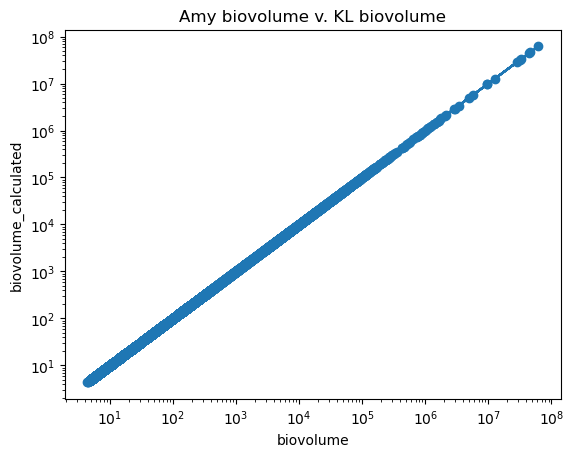

In [334]:
# Check my calculation versus Amy's ... 
plt.plot(df['biovolume'], df['biovolume_calculated'], marker='o', linestyle='-')

# Adding labels and title
plt.xlabel('biovolume')
plt.ylabel('biovolume_calculated')
plt.title('Amy biovolume v. KL biovolume')
plt.xscale('log')
plt.yscale('log')

# Display the plot
plt.show()

Make two df from df so I can work on HPLC data and flowcam data separately...will later merge together into df for the CMAP export file.\
For HPLC data do not need to do anything, but the flowcam data need to be grouped/added/summarized 

In [335]:
#export the full list...one row for each particle, this is large but only need it as a double-check
#df.to_excel('data/thinking.xlsx')

In [336]:
#make a copy to keep full list:
df_HPLC = df.copy()
df_fc = df.copy()
del(df)

In [337]:
#start with the pigments
basics = ['cruise','date_cmap','depth','lat','lon','sampleType']
#do the pigments separately and then merge into the other list...not actually sure if the times match up, but we shall see

pigments = ['allo',
       'alpha-beta-car', 'but-fuco', 'chl_c1c2', 'chl_c3', 'chlide_a',
       'diadino', 'diato', 'dp', 'dv_chl_a', 'dv_chl_b', 'fuco', 'gyro',
       'hex-fuco', 'lut', 'mv_chl_a', 'mv_chl_b', 'neo', 'perid', 'phide_a',
       'phytin_a', 'ppc', 'ppc_tcar', 'ppc_tpg', 'pras', 'psc', 'psc_tcar',
       'psp', 'psp_tpg', 'tacc', 'tacc_tchla', 'tcar', 'tchl', 'tchl_tcar',
       'tchla_tpg', 'tot_chl_a', 'tot_chl_b', 'tot_chl_c', 'tpg', 'viola',
       'zea']

In [338]:
#note there are some duplicate HPLC samples (one per cast it seems, so this will drop the second sample)
df_HPLC = df_HPLC.groupby(basics).agg('first').reset_index()

In [339]:
keep_columns = basics + pigments
df_HPLC = df_HPLC[[col for col in keep_columns if col in df_HPLC.columns]]

df_HPLC = df_HPLC[df_HPLC['tpg'].notna()]
df_HPLC.head()

,cruise,date_cmap,depth,lat,lon,sampleType,allo,alpha-beta-car,but-fuco,chl_c1c2,...,tcar,tchl,tchl_tcar,tchla_tpg,tot_chl_a,tot_chl_b,tot_chl_c,tpg,viola,zea
6,AE2503,2025-03-04T17:30:00Z,4.0,31.648,-64.1112,HPLC,NaN,0.008,0.009,0.008,...,0.078,0.104,1.33,0.45,0.082,0.006,0.016,0.182,0.001,0.026
7,AE2503,2025-03-04T17:30:00Z,40.0,31.648,-64.1112,HPLC,NaN,0.011,0.012,0.011,...,0.097,0.147,1.52,0.47,0.114,0.010,0.023,0.244,0.001,0.030
8,AE2503,2025-03-04T17:30:00Z,80.0,31.648,-64.1112,HPLC,0.001,0.019,0.027,0.023,...,0.172,0.289,1.68,0.46,0.212,0.024,0.053,0.461,0.001,0.033
9,AE2503,2025-03-04T17:30:00Z,120.0,31.648,-64.1112,HPLC,0.002,0.011,0.020,0.015,...,0.105,0.196,1.87,0.45,0.134,0.026,0.036,0.301,NaN,0.015
10,AE2503,2025-03-04T17:30:00Z,160.0,31.648,-64.1112,HPLC,0.001,0.005,0.017,0.010,...,0.062,0.126,2.03,0.44,0.082,0.019,0.025,0.188,NaN,0.007


In [340]:
#now move on to the Flowcam data
df_fc['data_provider_category_manual'].unique()

array(['redpico', 'rednano', 'bead', 'Unknowns', 'Trichodesmium',
       'blurry', 'Alveolata', 'Rhizaria', 'detritus', 'Bacillariophyta',
       'Animalia', 'artefact', nan, 'Diatoms', 'Metazoa', 'living<',
       'bubble'], dtype=object)

In [341]:
df_fc.columns

Index(['objectdetails', 'associated_files', 'associated_file_types', 'depth',
       'volume_sampled_ml', 'volume_imaged_ml',
       'data_provider_category_manual', 'scientificname_manual',
       'scientificnameid_manual', 'area_cross_section',
       'length_representation', 'width_representation',
       'equivalent_spherical_diameter', 'biovolume', 'cruise', 'sampleType',
       'biovolume_calculated', 'abundance_perL', 'biovolume_perL', 'lat',
       'lon', 'date_cmap', 'volnet', 'splitfraction',
       'particle_dilution_factor', 'hplc_gsfc_id', 'station', 'water_depth',
       'bottle', 'date', 'time', 'volfilt', 'sample', 'allo', 'alpha-beta-car',
       'but-fuco', 'chl_c1c2', 'chl_c3', 'chlide_a', 'diadino', 'diato', 'dp',
       'dv_chl_a', 'dv_chl_b', 'fuco', 'gyro', 'hex-fuco', 'lut', 'mv_chl_a',
       'mv_chl_b', 'neo', 'perid', 'phide_a', 'phytin_a', 'ppc', 'ppc_tcar',
       'ppc_tpg', 'pras', 'psc', 'psc_tcar', 'psp', 'psp_tpg', 'tacc',
       'tacc_tchla', 'tcar', '

In [342]:
#these are the caegories I will keep for the flowcam data (note the nan values were the HPLC rows)
catsKeep = ['redpico', 'rednano', 'Trichodesmium',
       'Alveolata', 'Rhizaria', 'Bacillariophyta',
       'Animalia', 'Diatoms', 'Metazoa']

df_fc = df_fc[df_fc['data_provider_category_manual'].isin(catsKeep)]

###mmm...cannot just use count need to add up the numbers calculated in particles per L
df_fc = df_fc.groupby(basics + ['data_provider_category_manual']).agg(
    abundance_perL=('abundance_perL', 'sum'),
    biovolume_perL=('biovolume_perL', 'sum')
    ).reset_index()

#do some rounding so we are not saving so many significant digits
df_fc = df_fc.round({'abundance_perL': 1, 'biovolume_perL': 1})

In [343]:
df_fc.head()

,cruise,date_cmap,depth,lat,lon,sampleType,data_provider_category_manual,abundance_perL,biovolume_perL
0,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Alveolata,6096.9,100454276.1
1,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Rhizaria,1108.5,2616867.3
2,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Trichodesmium,2771.3,385744202.0
3,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,rednano,1446624.5,318167407.7
4,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,redpico,613568.3,6045542.2


In [344]:
#recombine the HPLC data with the Flowcam data
df = df_fc.merge(df_HPLC, on=['cruise', 'date_cmap', 'depth','lat','lon','sampleType'], how='outer')

In [345]:
df.head()

,cruise,date_cmap,depth,lat,lon,sampleType,data_provider_category_manual,abundance_perL,biovolume_perL,allo,...,tcar,tchl,tchl_tcar,tchla_tpg,tot_chl_a,tot_chl_b,tot_chl_c,tpg,viola,zea
0,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Alveolata,6096.9,100454276.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Rhizaria,1108.5,2616867.3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,Trichodesmium,2771.3,385744202.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,rednano,1446624.5,318167407.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AE2503,2025-03-04T16:41:00Z,4.8,31.648,-64.111,FlowcamBottleAuto,redpico,613568.3,6045542.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [346]:
# need a few more steps to put this into CMAP format
# Required variables are time, lat, lon, depth #df = pd.DataFrame(columns=['time','lat','lon','depth'])

target_col = "depth"
new_order = [target_col] + [col for col in df.columns if col != target_col]
df = df[new_order]

target_col = "lon"
new_order = [target_col] + [col for col in df.columns if col != target_col]
df = df[new_order]

target_col = "lat"
new_order = [target_col] + [col for col in df.columns if col != target_col]
df = df[new_order]

target_col = "date_cmap"
new_order = [target_col] + [col for col in df.columns if col != target_col]
df = df[new_order]

df = df.rename(columns = {'date_cmap': "time"})

now do some plotting to see that I haven't gone off the deep end

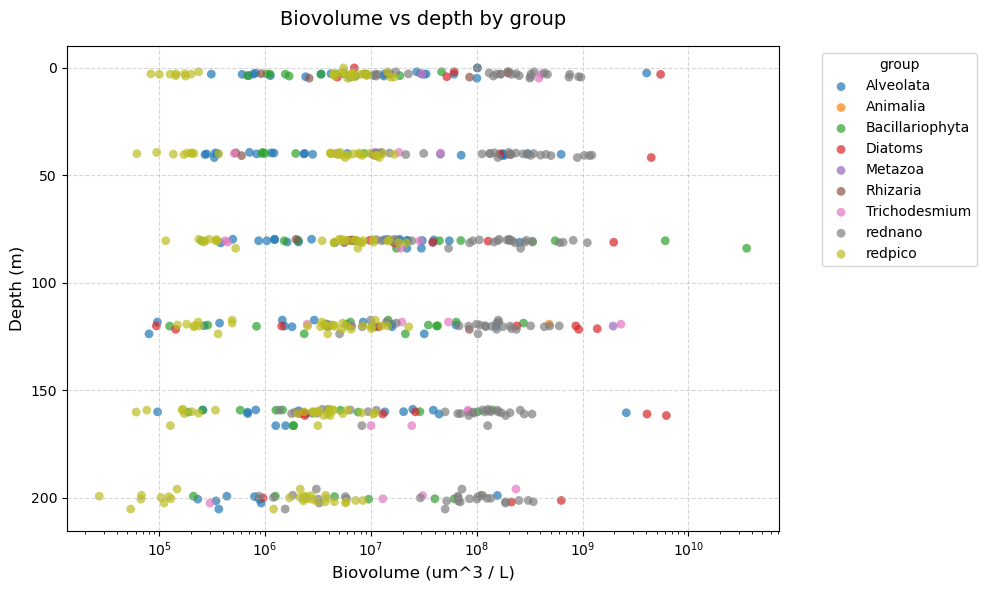

In [347]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Group by category and plot each subset to automatically apply unique colors
grouped = df.groupby('data_provider_category_manual')

for name, group in grouped:
    ax.scatter(
        group['biovolume_perL'], 
        group['depth'], 
        label=name, 
        alpha=0.7, 
        edgecolors='none', 
        s=40  # Dot size
    )

# 3. Invert Y-axis so greater depths are at the bottom
ax.invert_yaxis()

# 4. Add labels, title, and styling
ax.set_xlabel('Biovolume (um^3 / L)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Biovolume vs depth by group', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Place the legend outside the plot box so it doesn't overlap data points
ax.legend(title='group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

In [348]:
df.columns

Index(['time', 'lat', 'lon', 'depth', 'cruise', 'sampleType',
       'data_provider_category_manual', 'abundance_perL', 'biovolume_perL',
       'allo', 'alpha-beta-car', 'but-fuco', 'chl_c1c2', 'chl_c3', 'chlide_a',
       'diadino', 'diato', 'dp', 'dv_chl_a', 'dv_chl_b', 'fuco', 'gyro',
       'hex-fuco', 'lut', 'mv_chl_a', 'mv_chl_b', 'neo', 'perid', 'phide_a',
       'phytin_a', 'ppc', 'ppc_tcar', 'ppc_tpg', 'pras', 'psc', 'psc_tcar',
       'psp', 'psp_tpg', 'tacc', 'tacc_tchla', 'tcar', 'tchl', 'tchl_tcar',
       'tchla_tpg', 'tot_chl_a', 'tot_chl_b', 'tot_chl_c', 'tpg', 'viola',
       'zea'],
      dtype='object')

In [349]:
df = df.sort_values(by = ['time','depth'])

In [350]:
df.head()

,time,lat,lon,depth,cruise,sampleType,data_provider_category_manual,abundance_perL,biovolume_perL,allo,...,tcar,tchl,tchl_tcar,tchla_tpg,tot_chl_a,tot_chl_b,tot_chl_c,tpg,viola,zea
468,2025-01-17T16:37:00Z,31.687,-64.107,0.0,AR8602,FlowcamBottleAuto,Alveolata,1116.1,101822118.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
469,2025-01-17T16:37:00Z,31.687,-64.107,0.0,AR8602,FlowcamBottleAuto,Diatoms,2232.1,6982377.8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
470,2025-01-17T16:37:00Z,31.687,-64.107,0.0,AR8602,FlowcamBottleAuto,rednano,632812.5,101321528.3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,2025-01-17T16:37:00Z,31.687,-64.107,0.0,AR8602,FlowcamBottleAuto,redpico,728236.6,5545392.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,2025-01-17T16:37:00Z,31.687,-64.107,1.8,AR8602,FlowcamBottleTrigger,Diatoms,1099.3,61211595.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


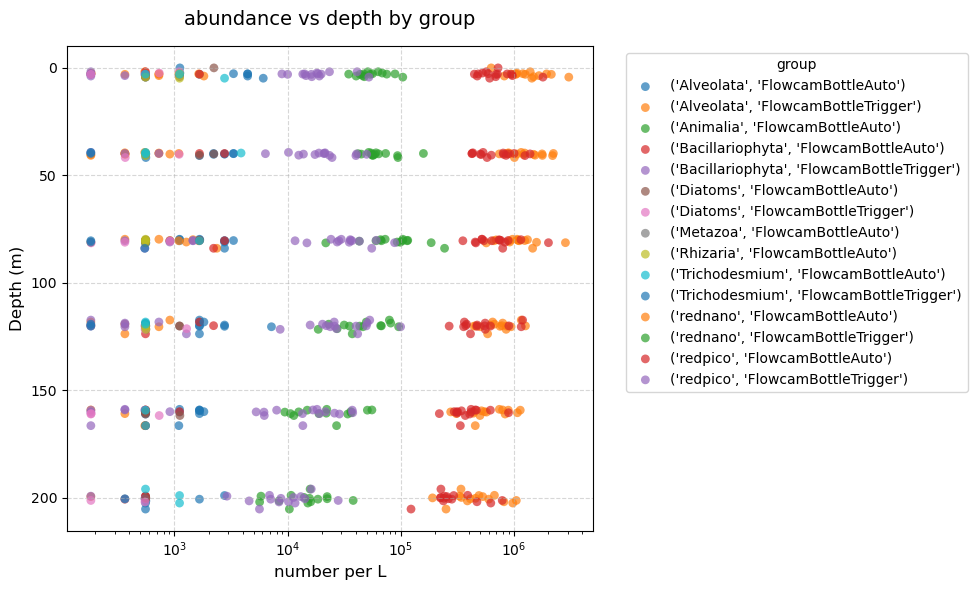

In [362]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Group by category and plot each subset to automatically apply unique colors
grouped = df.groupby(['data_provider_category_manual','sampleType'])

for name, group in grouped:
    ax.scatter(
        group['abundance_perL'], 
        group['depth'], 
        label=name, 
        alpha=0.7, 
        edgecolors='none', 
        s=40  # Dot size
    )

# 3. Invert Y-axis so greater depths are at the bottom
ax.invert_yaxis()

# 4. Add labels, title, and styling
ax.set_xlabel('number per L', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('abundance vs depth by group', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Place the legend outside the plot box so it doesn't overlap data points
ax.legend(title='group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('data/sampleTypeQuestion_allGroups.png', bbox_inches='tight') 
plt.show()

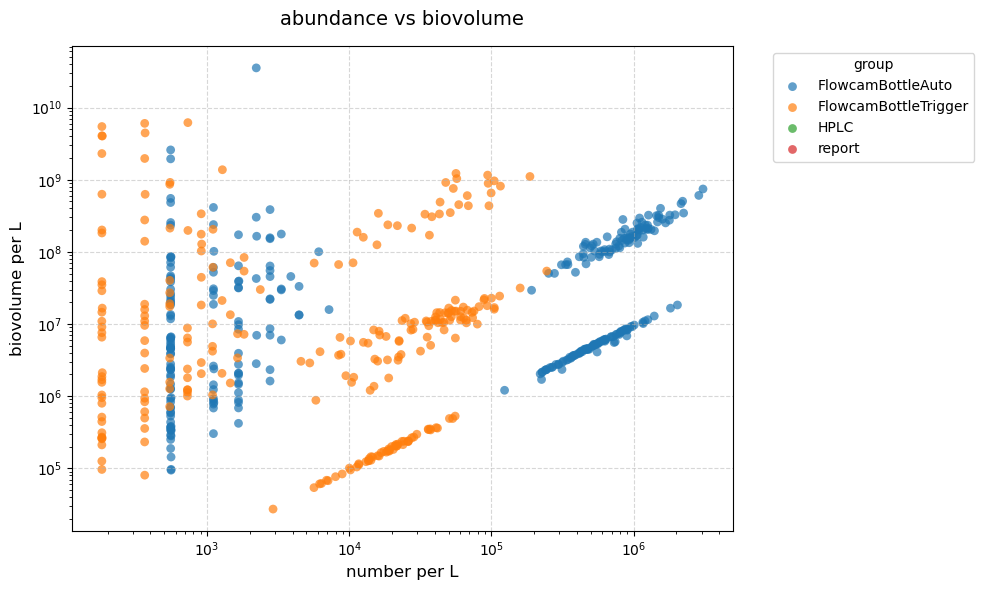

In [352]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Group by category and plot each subset to automatically apply unique colors
#grouped = df.groupby('data_provider_category_manual')
grouped = df.groupby('sampleType')

for name, group in grouped:
    ax.scatter(
        group['abundance_perL'], 
        group['biovolume_perL'], 
        label=name, 
        alpha=0.7, 
        edgecolors='none', 
        s=40  # Dot size
    )

ax.set_xscale('log')
ax.set_yscale('log')

# 4. Add labels, title, and styling
ax.set_xlabel('number per L', fontsize=12)
ax.set_ylabel('biovolume per L', fontsize=12)
ax.set_title('abundance vs biovolume', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Place the legend outside the plot box so it doesn't overlap data points
ax.legend(title='group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

C:\Users\LaneyLab\AppData\Local\Temp\ipykernel_31424\1573700387.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


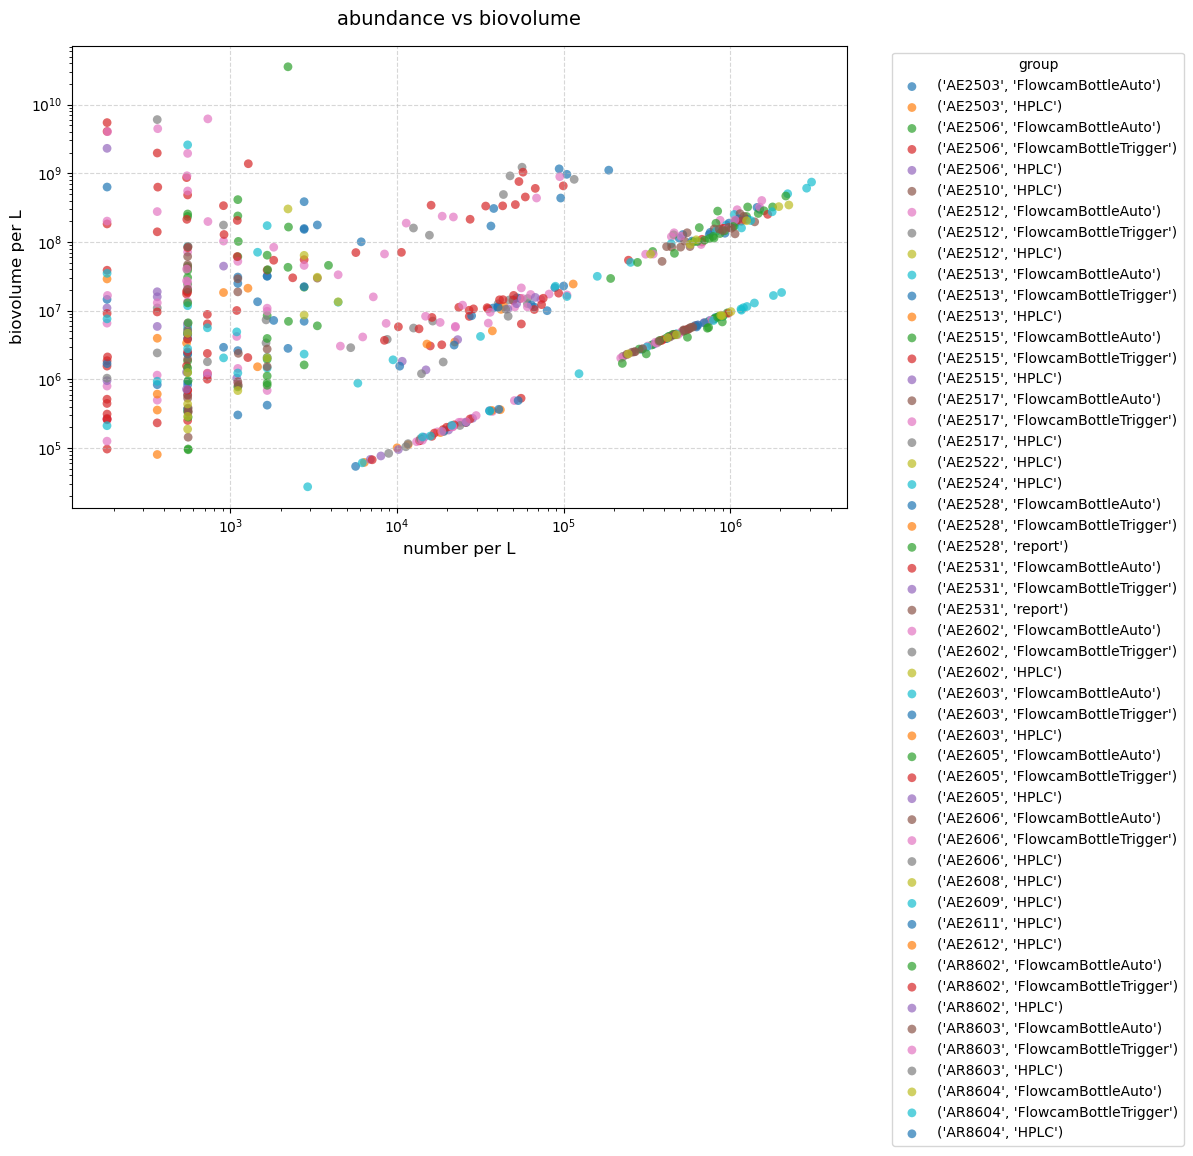

In [353]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Group by category and plot each subset to automatically apply unique colors
grouped = df.groupby(['cruise','sampleType'])

for name, group in grouped:
    ax.scatter(
        group['abundance_perL'], 
        group['biovolume_perL'], 
        label=name, 
        alpha=0.7, 
        edgecolors='none', 
        s=40  # Dot size
    )

ax.set_xscale('log')
ax.set_yscale('log')

# 4. Add labels, title, and styling
ax.set_xlabel('number per L', fontsize=12)
ax.set_ylabel('biovolume per L', fontsize=12)
ax.set_title('abundance vs biovolume', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Place the legend outside the plot box so it doesn't overlap data points
ax.legend(title='group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

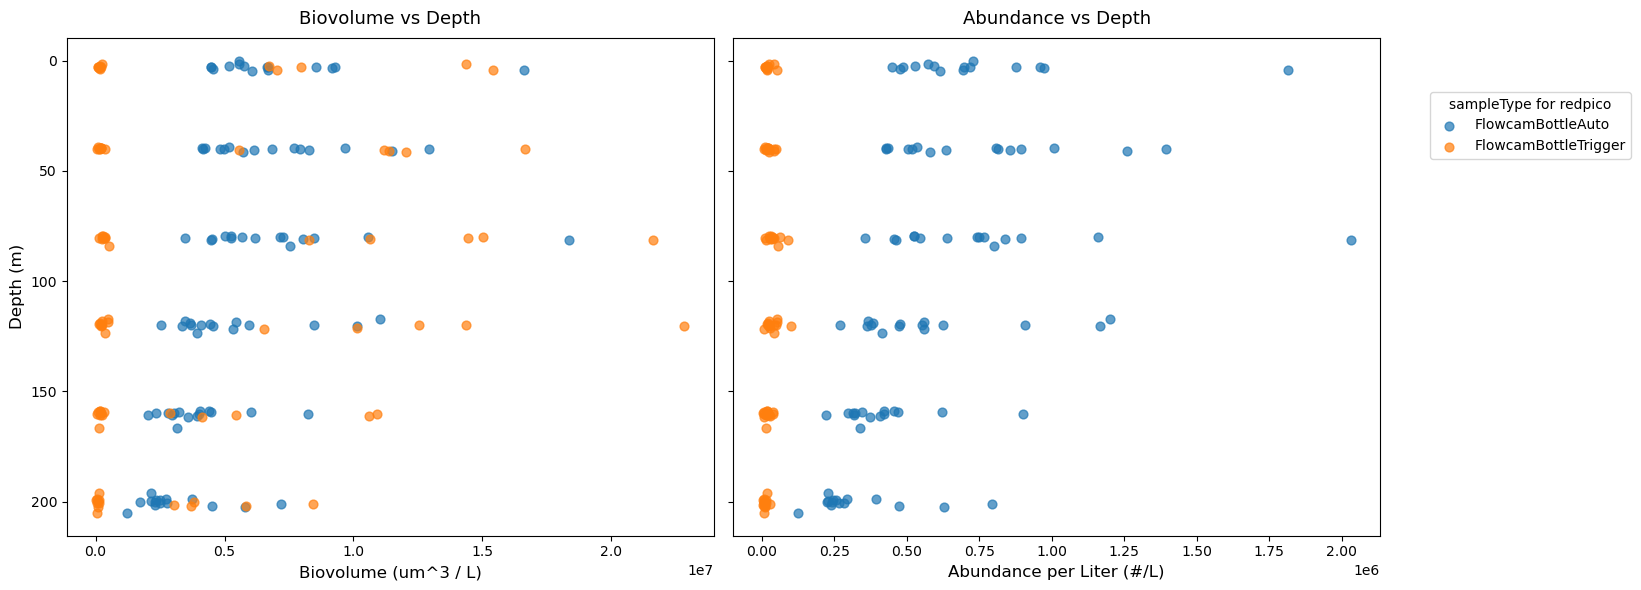

In [354]:
#what if I only plot one group and use colors for cruise?

# 1. Filter the DataFrame for 'diatoms' only
df_diatoms = df[df['data_provider_category_manual'] == 'redpico']

# 2. Create the side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 3. Group the filtered data by 'cruise'
grouped_cruise = df_diatoms.groupby('sampleType')

# 4. Loop through each cruise and plot its data points
for cruise_name, group in grouped_cruise:
    # Subplot 1: Biovolume vs Depth for this cruise
    ax1.scatter(
        group['biovolume_perL'], 
        group['depth'], 
        label=cruise_name, 
        alpha=0.7, 
        s=40
    )
    
    # Subplot 2: Particles per Liter vs Depth for this cruise
    ax2.scatter(
        group['abundance_perL'], 
        group['depth'], 
        label=cruise_name, 
        alpha=0.7, 
        s=40
    )

# 5. Invert Y-axis so deeper values are at the bottom
ax1.invert_yaxis()

# 6. Format Subplot 1 (Biovolume)
ax1.set_xlabel('Biovolume (um^3 / L)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_title('Biovolume vs Depth', fontsize=13, pad=10)
# ax1.grid(True, linestyle='--', alpha=0.5)
#ax1.set_xscale('log')

# 7. Format Subplot 2 (Particles per Liter)
ax2.set_xlabel('Abundance per Liter (#/L)', fontsize=12)
ax2.set_title('Abundance vs Depth', fontsize=13, pad=10)
# ax2.grid(True, linestyle='--', alpha=0.5)

# 8. Add a single, shared legend for the cruises to the right
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='sampleType for redpico', bbox_to_anchor=(1.02, 0.85), loc='upper left')

plt.tight_layout()
plt.savefig('data/sampleTypeQuestion.png', bbox_inches='tight') 
plt.show()


In [355]:
'''
Work on the second sheet: metadata about the variables; use the CMAP dataset template to setup the dataframe 
so I get the column headers right
'''
fName = 'datasetTemplate.xlsx' #downloaded from CMAP website
sheet_name = 'vars_meta_data'
vars = pd.read_excel(fName, sheet_name=sheet_name)
cols = vars.columns.tolist()
#df2 will be the dataframe with the metadata about the variables, set it up empty here
nVariables = df.shape[1]
df2 = pd.DataFrame(columns=cols,index = pd.RangeIndex(0,nVariables,1))

# this is only a partial list of variables for the moment
df2['var_short_name'] = df.columns
df2.loc[:,'var_long_name'] = ''
df2.loc[:,'var_sensor'] = ''
df2.loc[:,'var_unit'] = ''
df2.loc[:,('var_spatial_res')] = 'irregular'
df2.loc[:, ('var_temporal_res')] = 'irregular'
df2.loc[:,('var_discipline')] = 'biology'
df2.loc[:,('visualize')] = 0 #many would be hard to visualize these one at a time: edit later

#add the keywords, nothing fancy here
misc_keywords = 'BIOS-SCOPE, BIOS, Simons Foundation International, bio, biogeo, biogeochemistry, biology, flowCAM, Zooscan, net tows, Discrete, Bottle, cruise, Discrete, in situ, insitu, in-situ, North Atlantic Ocean, observation'
df2.loc[:,('var_keywords')] = misc_keywords      

In [356]:
#uncomment this out the first time to get the variable information, but then once the information is in Excel, read 
#the information that has been copied into fName = 'CMAP_variableMetadata_additions.xlsx'
#there is most certainly a better way to do this, but I am not going to deal with that now

# #SeaBASS does not appear to have a downloadable file with their variable names, though the information is here:
# #https://seabass.gsfc.nasa.gov/wiki/stdfields
# #copy/paste into Excel, tidy up, and use to get the details I need on units and long names
# fName = 'SeaBASS_variableNames.xlsx'
# vn = pd.read_excel(fName,sheet_name = 'variables')
# vn['var_short_name'] = vn['Field name'].str.lower() #otherwise I miss some of the matches :(

# df2 = pd.merge(df2,vn,how='left')
# df2['var_long_name'] = df2['Description']
# df2['var_unit'] = df2['Units']
# df2 = df2.drop(columns = ['Description','Units','Field name'])

In [357]:
#there are a few pieces of metadata that CMAP wants that will be easier to track in an Excel file -
#make the file once, and then update as needed for future BCO-DMO datasets.
#The keywords include cruises, and all possible names for a variable. I wonder if
#CMAP has that information available in a way that can be searched?
#These are all one-offs...so it's rather hard to automate. I am coming to the idea it will be easier to manually annotate the files.
#Come back to this later.

# # Note that I made the Excel file after I started down this rabbit hole with the sensors. It will probably make sense
# #to pull the sensor information from the file as well.
fName = 'CMAP_variableMetadata_additions.xlsx'
sheetName = 'PVST_BATS_PLANKTON'

moreMD = pd.read_excel(fName,sheet_name = sheetName)

# #suffixes are added to column name to keep them separate; '' adds nothing while '_td' adds _td that can get deleted next
df2 = moreMD.merge(df2[['var_short_name','var_keywords']],on='var_short_name',how='right',suffixes=('', '_td',))
# # Discard the columns that acquired a suffix:
df2 = df2[[c for c in df2.columns if not c.endswith('_td')]]

In [358]:
'''
Gather the details I need about the dataset
'''
project_description = 'The data provided by this project is the abundance and taxonomic information for the 5-300 µm planktonic community captured via imaging with a FlowCam. Target depths for both the niskin-based FlowCam samples include surface, 40, 80, 120, 160, and 200. The FlowCam was run in both trigger and automated mode at 10X for each bottle sample to enumerate and classify photosynthetic and non-photosynthetic organisms.'

# gather up the dataset_meta_data into df3

df3 = pd.DataFrame({
    'dataset_short_name': ['BS_PLANKTON_1'],
    'dataset_long_name': ['BS_PVST_BATS_PLANKTON'], 
    'dataset_version': ['1.0'],
    'dataset_release_date': [date.today()],
    'dataset_make': ['observation'],
    'dataset_source': ['Amy Maas, Bermuda Institute of Ocean Sciences - Arizona State University'],
    'dataset_distributor': ['Amy Maas, Bermuda Institute of Ocean Sciences - Arizona State University'],
    'dataset_acknowledgement': ['This work supported by funding from NASA.'],
    'dataset_history': [''],
    'dataset_description': [project_description],
    'dataset_references': ['DOI is 10.5067/SeaBASS/PVST_BATS_PLANKTON/DATA001; '],
    'climatology': [0]
    })

In [359]:
#insert the list of unique cruises from the data pulled from the folder structure
df3 = pd.concat([df3,pd.DataFrame(unCruises)],axis=1)
df3 = df3.rename(columns={df3.columns[-1]: 'cruise_names'})

In [360]:
fName_CMAP = 'data/' + 'BIOS-SCOPE_SeaBASS_' + 'PVST_BATS_PLANKTON' + '.xlsx'
dataset_names = {'data': df, 'dataset_meta_data': df3, 'vars_meta_data': df2}
with pd.ExcelWriter(fName_CMAP) as writer:
    for sheet_name, data in dataset_names.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)

In [361]:
# uncomment out the next line if I want to put code that will not be executed below this point
raise SystemExit("Stop execution here")

SystemExit: Stop execution here

C:\Users\LaneyLab\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3465: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# #reorder to make it easier to figure out what is going on with the calculations
# target_col = "filename"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "sampleType"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "cruise"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "particles_perL"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "volume"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "volfilt"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "volume_sampled_ml"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "volume_imaged_ml"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "volnet"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "splitfraction"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "particle_dilution_factor"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]

# target_col = "biovolume"
# new_order = [target_col] + [col for col in df.columns if col != target_col]
# df = df[new_order]


# #figure out cruise-by-cruise which are the cases where I have -999 in calculations...for each sampleType ...should be all set with the Flowcam data.

# #add a new column to df: calc 
# df['calc'] = (df['particles_perL']!=-999).astype(int)

# #don't need report and HPLC here - data in the Excel file is count each event (not the values themselves)
# df3 = df[~df['sampleType'].isin(['HPLC','report'])]
# dfg2 = df3.groupby(by = ['sampleType','cruise','calc']).count()
# dfg2.to_excel('data/summarizeCalculations_Export.xlsx',index=True)